In [2]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

In [3]:
# 1. Data Collection: 
loan_df = pd.read_csv('loan_data.csv')
loan_df

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved
...,...,...,...,...,...,...,...
23995,I need funds to pay for my daughter's college ...,195242,817,16403,24.32,employed,Approved
23996,I need financial assistance to launch my own Y...,150246,729,101572,9.97,employed,Rejected
23997,I need money to open a small bookstore and café.,64571,650,30533,57.35,employed,Rejected
23998,I want to buy a car for my rideshare business ...,115825,418,89837,10.37,unemployed,Rejected


In [4]:
loan_df.columns

Index(['Text', 'Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio',
       'Employment_Status', 'Approval'],
      dtype='object')

In [5]:
# checking the null values
# 2. Data Preprocessing:
# Cleaning: Handling missing data, removing duplicates, and correcting inconsistencies.
# Feature Engineering: Creating new features or transforming existing features (e.g., scaling, encoding).
# Data Transformation: This includes normalizing or scaling numerical features and encoding categorical variables (e.g., using One-Hot Encoding, Label Encoding).
# Splitting: Dividing the data into training and testing sets.

loan_df.isnull().sum()

Text                 0
Income               0
Credit_Score         0
Loan_Amount          0
DTI_Ratio            0
Employment_Status    0
Approval             0
dtype: int64

In [6]:
# droping the unnecessary columns
loan_df.drop('Text',axis=1,inplace=True)

In [7]:
# knowing the diff types of values in the employment_status column
loan_df['Employment_Status'].value_counts()

Employment_Status
unemployed    12007
employed      11993
Name: count, dtype: int64

In [8]:
# Feature Engineering

from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [9]:
# converting the char data to numeric data using onehotencoding
pd.get_dummies(loan_df,columns=['Employment_Status'],dtype=int)

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Approval,Employment_Status_employed,Employment_Status_unemployed
0,26556,581,8314,79.26,Rejected,1,0
1,197392,389,111604,22.14,Rejected,1,0
2,44561,523,34118,45.44,Rejected,1,0
3,190363,729,118757,10.22,Rejected,0,1
4,61853,732,19210,44.13,Approved,1,0
...,...,...,...,...,...,...,...
23995,195242,817,16403,24.32,Approved,1,0
23996,150246,729,101572,9.97,Rejected,1,0
23997,64571,650,30533,57.35,Rejected,1,0
23998,115825,418,89837,10.37,Rejected,0,1


In [10]:
LabelEncoder_emp_status1 = LabelEncoder()

In [11]:
# converting the char data to numeric data using labelEncoder 
LabelEncoder_emp_status = LabelEncoder()
loan_df['Emp_status'] = LabelEncoder_emp_status.fit_transform(loan_df['Employment_Status'])


In [12]:
loan_df

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval,Emp_status
0,26556,581,8314,79.26,employed,Rejected,0
1,197392,389,111604,22.14,employed,Rejected,0
2,44561,523,34118,45.44,employed,Rejected,0
3,190363,729,118757,10.22,unemployed,Rejected,1
4,61853,732,19210,44.13,employed,Approved,0
...,...,...,...,...,...,...,...
23995,195242,817,16403,24.32,employed,Approved,0
23996,150246,729,101572,9.97,employed,Rejected,0
23997,64571,650,30533,57.35,employed,Rejected,0
23998,115825,418,89837,10.37,unemployed,Rejected,1


In [13]:
loan_df['Approval_value'] = LabelEncoder_emp_status1.fit_transform(loan_df['Approval'])

In [14]:
loan_df

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval,Emp_status,Approval_value
0,26556,581,8314,79.26,employed,Rejected,0,1
1,197392,389,111604,22.14,employed,Rejected,0,1
2,44561,523,34118,45.44,employed,Rejected,0,1
3,190363,729,118757,10.22,unemployed,Rejected,1,1
4,61853,732,19210,44.13,employed,Approved,0,0
...,...,...,...,...,...,...,...,...
23995,195242,817,16403,24.32,employed,Approved,0,0
23996,150246,729,101572,9.97,employed,Rejected,0,1
23997,64571,650,30533,57.35,employed,Rejected,0,1
23998,115825,418,89837,10.37,unemployed,Rejected,1,1


In [15]:
loan_df.drop('Employment_Status',axis=1,inplace=True)
# emp_status = employeed = 0 ,unempl = 1

In [16]:
loan_df

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Approval,Emp_status,Approval_value
0,26556,581,8314,79.26,Rejected,0,1
1,197392,389,111604,22.14,Rejected,0,1
2,44561,523,34118,45.44,Rejected,0,1
3,190363,729,118757,10.22,Rejected,1,1
4,61853,732,19210,44.13,Approved,0,0
...,...,...,...,...,...,...,...
23995,195242,817,16403,24.32,Approved,0,0
23996,150246,729,101572,9.97,Rejected,0,1
23997,64571,650,30533,57.35,Rejected,0,1
23998,115825,418,89837,10.37,Rejected,1,1


In [17]:
loan_df.drop('Approval',axis=1,inplace=True)
# approved = 0 , rejected = 1

In [18]:
loan_df

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Emp_status,Approval_value
0,26556,581,8314,79.26,0,1
1,197392,389,111604,22.14,0,1
2,44561,523,34118,45.44,0,1
3,190363,729,118757,10.22,1,1
4,61853,732,19210,44.13,0,0
...,...,...,...,...,...,...
23995,195242,817,16403,24.32,0,0
23996,150246,729,101572,9.97,0,1
23997,64571,650,30533,57.35,0,1
23998,115825,418,89837,10.37,1,1


In [19]:
input_data2 = loan_df.iloc[:,:-1]

In [20]:
input_data2

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Emp_status
0,26556,581,8314,79.26,0
1,197392,389,111604,22.14,0
2,44561,523,34118,45.44,0
3,190363,729,118757,10.22,1
4,61853,732,19210,44.13,0
...,...,...,...,...,...
23995,195242,817,16403,24.32,0
23996,150246,729,101572,9.97,0
23997,64571,650,30533,57.35,0
23998,115825,418,89837,10.37,1


In [21]:
# 3. Model Selection:

# Choosing the appropriate algorithm for your task (e.g., Decision Trees, Random Forest, Linear Regression, Neural Networks).
# You can also experiment with different models in this stage and later choose the best one.

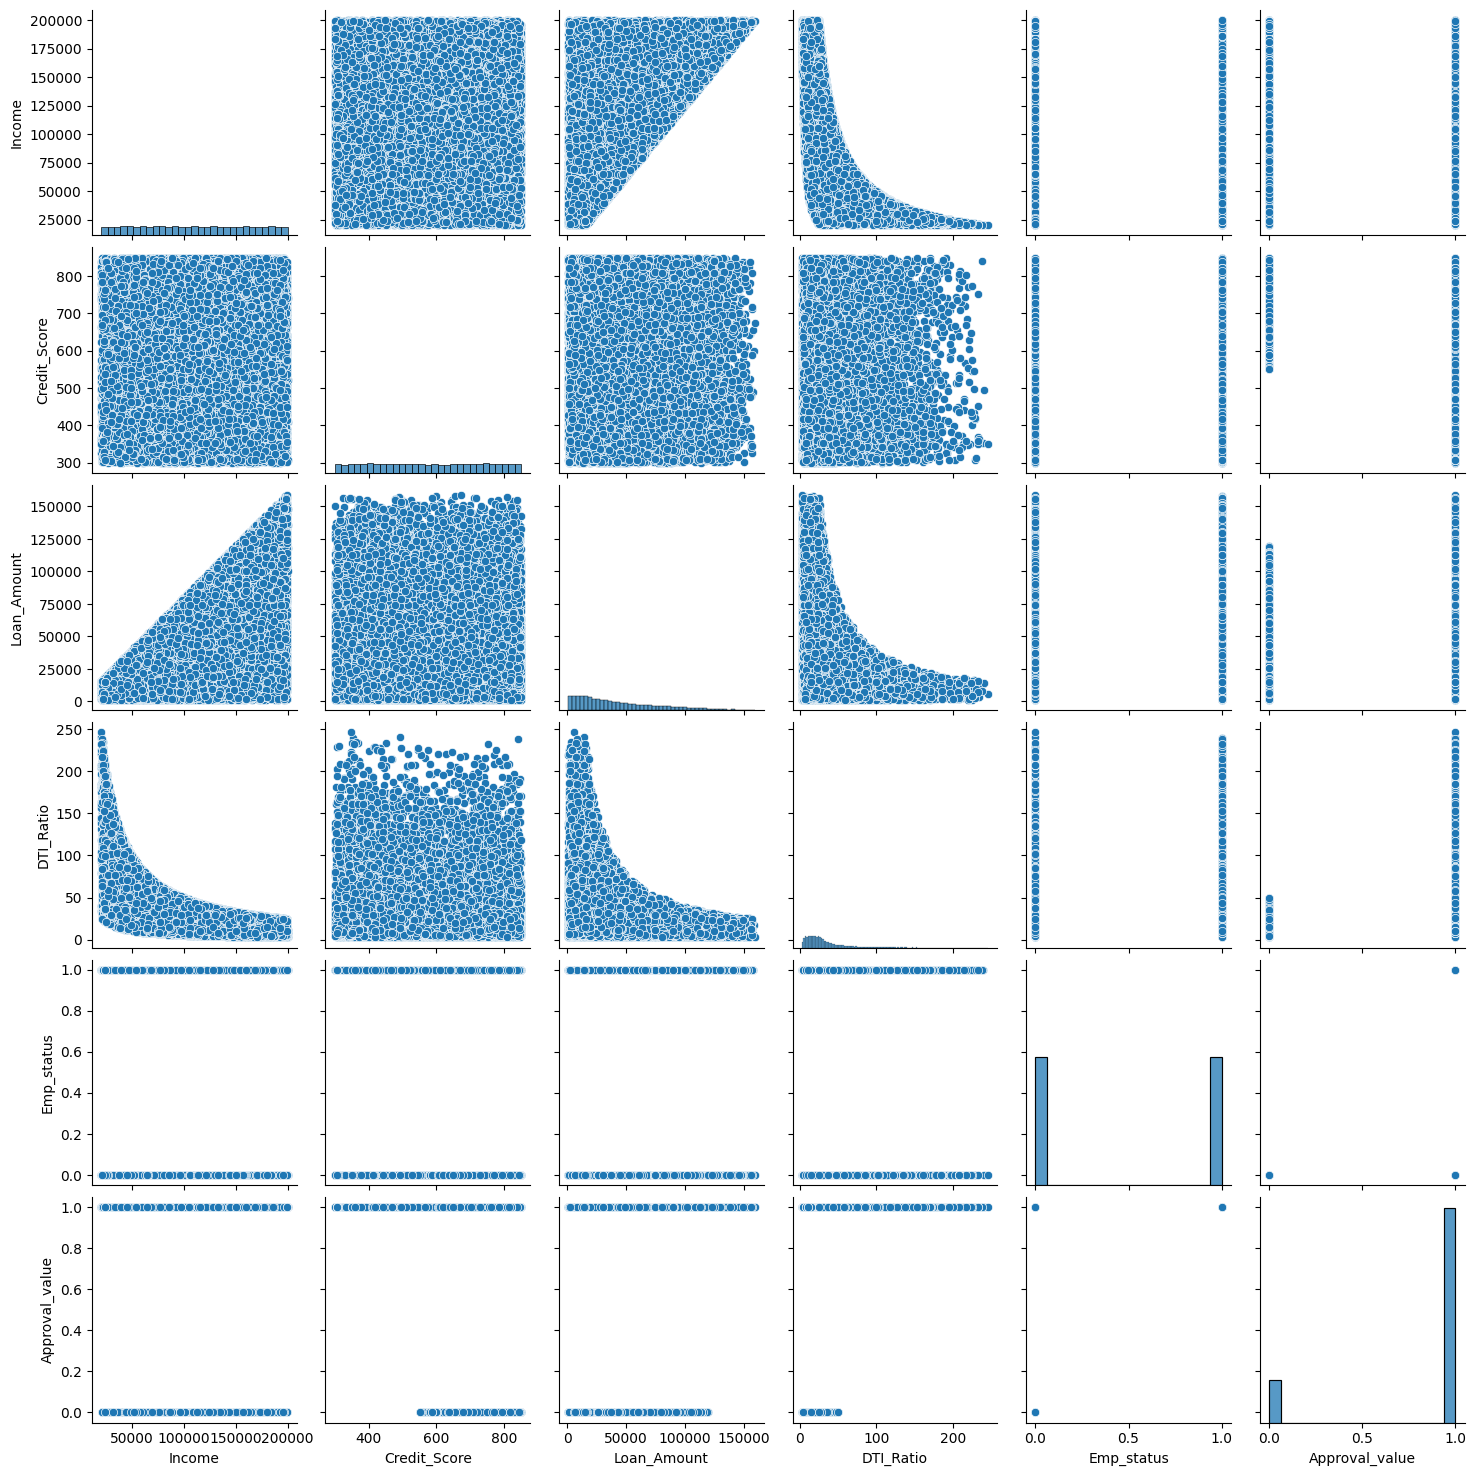

In [22]:
sns.pairplot(data=loan_df)

In [23]:
# input_data = loan_df.drop('Approval_value',axis=1)
output_data = loan_df[['Approval_value']]
# output_data.dtypes 
output_data

,Approval_value
0,1
1,1
2,1
3,1
4,0
...,...
23995,0
23996,1
23997,1
23998,1


In [24]:
output_data_df = pd.DataFrame(data=output_data,columns=output_data.columns)
output_data_df

,Approval_value
0,1
1,1
2,1
3,1
4,0
...,...
23995,0
23996,1
23997,1
23998,1


In [25]:
input_data.dtypes

NameError: name 'input_data' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaler_input = scaler.fit_transform(input_data)

In [ ]:
scaler_input_data = pd.DataFrame(data=scaler_input,columns=input_data.columns)
scaler_input_data


,Income,Credit_Score,Loan_Amount,DTI_Ratio,Emp_status
0,-1.620410,0.033159,-1.039701,1.378043,-1.000584
1,1.682134,-1.172687,1.939886,-0.389185,-1.000584
2,-1.272344,-0.331107,-0.295338,0.331690,-1.000584
3,1.546252,0.962665,2.146227,-0.757977,0.999417
4,-0.938060,0.981506,-0.725386,0.291161,-1.000584
...,...,...,...,...,...
23995,1.640571,1.515344,-0.806359,-0.321739,-1.000584
23996,0.770723,0.962665,1.650494,-0.765711,-1.000584
23997,-0.885517,0.466510,-0.398754,0.700172,-1.000584
23998,0.105308,-0.990554,1.311977,-0.753336,0.999417


In [ ]:
scaler_data_loan =pd.concat([scaler_input_data,output_data_df],axis=1)
scaler_data_loan

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Emp_status,Approval_value
0,-1.620410,0.033159,-1.039701,1.378043,-1.000584,1
1,1.682134,-1.172687,1.939886,-0.389185,-1.000584,1
2,-1.272344,-0.331107,-0.295338,0.331690,-1.000584,1
3,1.546252,0.962665,2.146227,-0.757977,0.999417,1
4,-0.938060,0.981506,-0.725386,0.291161,-1.000584,0
...,...,...,...,...,...,...
23995,1.640571,1.515344,-0.806359,-0.321739,-1.000584,0
23996,0.770723,0.962665,1.650494,-0.765711,-1.000584,1
23997,-0.885517,0.466510,-0.398754,0.700172,-1.000584,1
23998,0.105308,-0.990554,1.311977,-0.753336,0.999417,1


In [ ]:
x_data = scaler_data_loan.iloc[:,:-1]
y_data = scaler_data_loan['Approval_value']


In [ ]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,random_state=42,test_size=0.2)

In [ ]:
model1 = LogisticRegression()
model1.fit(x_train,y_train)

LogisticRegression()

In [26]:
model1.score(x_train,y_train)*100,model1.score(x_test,y_test) *100 # 0.9302083333333333
 # 0.9283333333333333

NameError: name 'model1' is not defined

In [ ]:
corr = loan_df.corr(numeric_only = True)
corr

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Emp_status,Approval_value
Income,1.000000,0.001201,0.590209,-0.655438,0.006210,-0.135574
Credit_Score,0.001201,1.000000,-0.006542,-0.002775,-0.006566,-0.351693
Loan_Amount,0.590209,-0.006542,1.000000,-0.386798,0.008209,0.085467
DTI_Ratio,-0.655438,-0.002775,-0.386798,1.000000,-0.007542,0.172182
Emp_status,0.006210,-0.006566,0.008209,-0.007542,1.000000,0.442970
Approval_value,-0.135574,-0.351693,0.085467,0.172182,0.442970,1.000000


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
x= loan_df.iloc[:,:-1]
y = loan_df['Approval_value']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(x_train,y_train)


c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
model.score(x_train,y_train)

0.9277604166666666

In [ ]:
model.score(x_test,y_test)

0.9252083333333333

In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
# output_data_df
input_data2

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Emp_status
0,26556,581,8314,79.26,0
1,197392,389,111604,22.14,0
2,44561,523,34118,45.44,0
3,190363,729,118757,10.22,1
4,61853,732,19210,44.13,0
...,...,...,...,...,...
23995,195242,817,16403,24.32,0
23996,150246,729,101572,9.97,0
23997,64571,650,30533,57.35,0
23998,115825,418,89837,10.37,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(input_data2, output_data_df, test_size=0.3, random_state=42)

In [ ]:
m = DecisionTreeClassifier()
m.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
m.score(X_train,y_train) # 1.0
# m.score(X_test,y_test) # 0.9965277777777778

1.0

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train,y_train)

c:\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [ ]:
rf_model.score(X_train,y_train)

0.9974901884535589

In [ ]:
rf_model.score(X_test,y_test)

0.9883877189263727

In [ ]:
import pickle

with open('model_decisiontree.pkl', 'wb') as file:
    pickle.dump(m, file)

In [ ]:
with open('model_decisiontree.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# loaded_model.predict([[26556,581,8314,79.26,0]])   # 1 
# loaded_model.predict([[197392,389,111604,22.14,0]]) # 1
# loaded_model.predict([[61853,732,19210,44.14,0]])  # 0
# 26556	581	8314	79.26   0
# 197392	389	111604	22.14	0	
# 61853	732	19210	44.13	0	0

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
import pickle
with open('labelEncode_data.pkl','wb') as file:
    pickle.dump(LabelEncoder_emp_status, file) 


In [ ]:
with open('labelEncode_data.pkl','rb') as file:
    loaded_labelencode = pickle.load(file)



In [ ]:
# loaded_labelencode.transform(['unemployed'])  # 1
loaded_labelencode.transform(['employed'])  # 0


array([0])